# Photon Counting Data Processing Pipeline

### Data Acquisition

All measurements were acquired using a sampling window of 1 s and a sampling rate of 10 MHz, corresponding to a total of 10 million samples per waveform.


### Noise Reference Measurement
(This assumption was made because we noticed that when changing the PMT control voltage, the noise levels maintained around -40mV~40mV.)

To characterize the electronic noise floor of the detection system, the PMT control voltage was first set to 0 V. Under this condition, ten independent waveform recordings were acquired.

The maximum voltage value from each waveform was extracted, and the biggest value observed across all ten recordings was selected as the noise reference:

$$
V_{\text{noise}} = -\max(V_{\text{abs(noise data)}})
$$

This value represents the largest noise excursion observed in the absence of PMT gain and is used as a baseline for threshold determination.


### Pulse Height Histogram Construction

The PMT control voltage was then increased to 0.85 V, and ten additional waveform recordings were acquired under identical acquisition conditions.

For each waveform:

1. Local minima were identified using a peak-finding algorithm applied to the inverted signal.
2. The voltage values corresponding to all detected minima were collected.
3. The minima from all ten files were pooled together.
4. A histogram of the minima voltages was generated to obtain the pulse-height distribution.

This histogram contains contributions from both noise fluctuations and photon-induced PMT pulses.

(Using histogram, we hope to see the clear boundary between noise and pulse so that we can determine the threshold based on this.)


### Threshold Determination

Local valleys in the pulse-height histogram were identified by searching for minima in the histogram counts.

Each detected valley voltage was compared with the previously determined noise reference.

Among all histogram valleys satisfying

$$
V_{\text{valley}} < V_{\text{noise}},
$$

the valley closest to the noise reference (i.e., the largest voltage) was selected as the counting threshold:

$$
V_{\text{th}} =
\max\left(
V_{\text{valley}}
 \big|
V_{\text{valley}} < V_{\text{noise}}
\right)
$$

This threshold represents the boundary between noise-dominated fluctuations and photon-induced pulse events.

For a more conservative photon-counting criterion, a stricter threshold may be defined as

$$
V_{\text{th,strict}}
=
V_{\text{th}}
-
5\sigma ,
$$

where ($\sigma$) is the standard deviation of the measured signal under 0.85V PMT control voltage.



### Photon Counting

For each of the ten waveform files acquired at a PMT control voltage of 0.85 V:

1. Local minima were detected using the same peak-finding parameters used during histogram generation.
2. Only minima satisfying were classified as photon events.

$$
V_{\text{min}} < V_{\text{th}}
$$

3. The total number of such minima was recorded as the photon count for that waveform.


### Output Metrics

The final analysis reports:

- Photon count for each waveform file.
- Mean photon count across all measurements.
- Standard deviation of the photon count.
- Minimum and maximum photon counts.
- Pulse-height histogram and selected threshold.
- Photon-count distribution across all measurements.

In [1]:
import csv
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.signal import find_peaks


In [2]:
# -----------------------------
# User-configurable parameters
# -----------------------------
# DAQ-specific loading is replaced here with oscilloscope .npz folders from
# data_scopecapture(notrigger).ipynb. Downstream analysis still consumes the
# same internal 1-D voltage waveform named "signal".
from scipy import signal

NOISE_DATA_FOLDER = "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/20260604_PMT_darkcount_control_voltage/PMT=0/data"
DATA_FOLDER  = "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/20260604_PMT_darkcount_control_voltage/PMT=0.65/data"

# Peak/minimum detection settings.
pulse_width = 200      # ns

PROMINENCE = 0.005

# Histogram display settings.
HIST_BINS = 200
HIST_YMAX = 500

data_dir = Path(DATA_FOLDER)
output_dir = Path(DATA_FOLDER)
npz_files = sorted(data_dir.glob("*.npz"))

if not npz_files:
    raise FileNotFoundError(f"No .npz files found in {data_dir}")

def load_signal(file):
    # Scope-compatible adapter: return the calibrated waveform in the same
    # 1-D internal representation used by the original DAQ workflow.
    with np.load(file) as data:
        return np.asarray(data["signal"]).reshape(-1)

# Inspect the first file to document the oscilloscope acquisition structure.
with np.load(npz_files[0]) as example_data:
    for key in example_data.keys():
        value = example_data[key]

    sample_rate = float(example_data["sample_rate"])

# Oscilloscope time-axis metadata is stored as sample_rate; convert it to the
# sampling interval expected by the unchanged pulse-distance calculations.
sampling_interval = 1e9 / sample_rate  # ns
n_samples = math.ceil(pulse_width / sampling_interval)


with np.load(npz_files[0]) as example_data:
    print(f"Example file: {npz_files[0].name}")
    print(f"Available keys: {list(example_data.keys())}")

    for key in example_data.keys():
        value = example_data[key]
        print(f"  {key}: shape={value.shape}, dtype={value.dtype}")

    signal = example_data["signal"]
    sample_rate = float(example_data["sample_rate"])

    n_points = len(signal)
    acquisition_time = n_points / sample_rate

    print(f"\nNumber of samples: {n_points}")
    print(f"Sample rate: {sample_rate/1e6:.2f} MSa/s")
    print(f"Sampling interval: {1e9/sample_rate:.2f} ns")
    print(f"Acquisition length: {acquisition_time*1e3:.3f} ms")

MINIMA_DISTANCE = n_samples
COUNT_DISTANCE = n_samples

Example file: data_001.npz
Available keys: ['signal', 'sample_rate', 'acquisition_time', 'channel']
  signal: shape=(10000000,), dtype=float64
  sample_rate: shape=(), dtype=float64
  acquisition_time: shape=(), dtype=float64
  channel: shape=(), dtype=<U5

Number of samples: 10000000
Sample rate: 10.00 MSa/s
Sampling interval: 100.00 ns
Acquisition length: 1000.000 ms


#### Data inspection

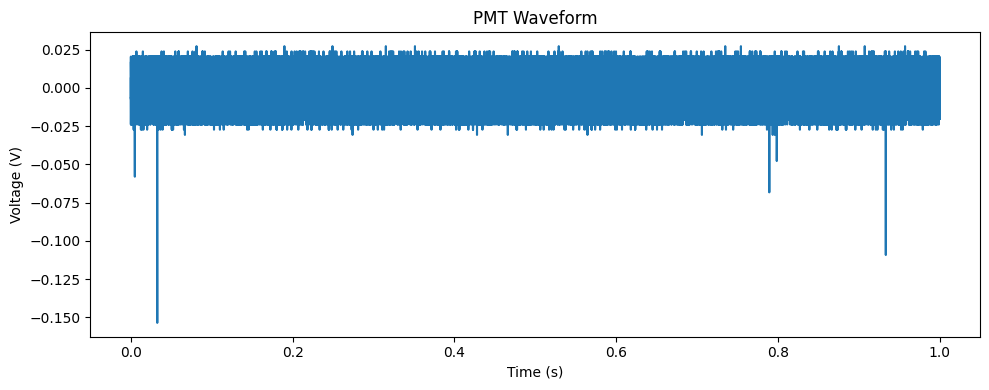

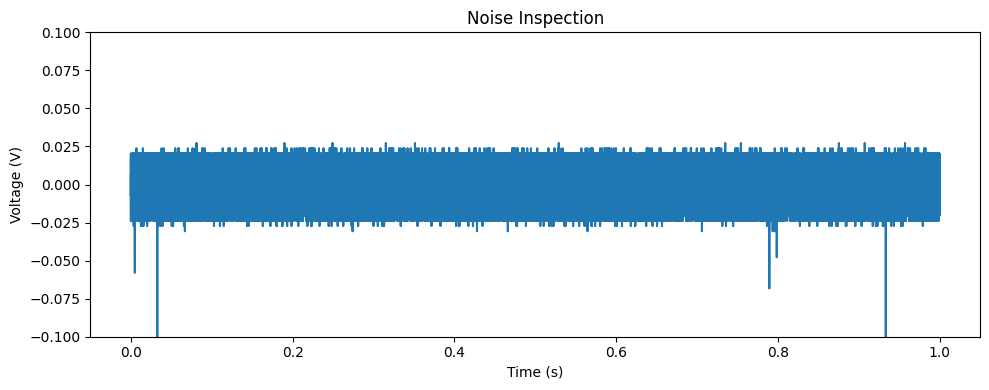

In [3]:
file = npz_files[0]

with np.load(file) as data:
    signal = data["signal"]
    sample_rate = float(data["sample_rate"])

time = np.arange(len(signal)) / sample_rate

for title, ylim in [
    ("PMT Waveform", None),
    ("Noise Inspection", (-0.1, 0.1)),
]:
    plt.figure(figsize=(10, 4))
    plt.plot(time, signal)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Total number of files: 10
Total number of signal samples: 100000000
Signal mean: 0.0048480305
Signal standard deviation: 0.0060628383


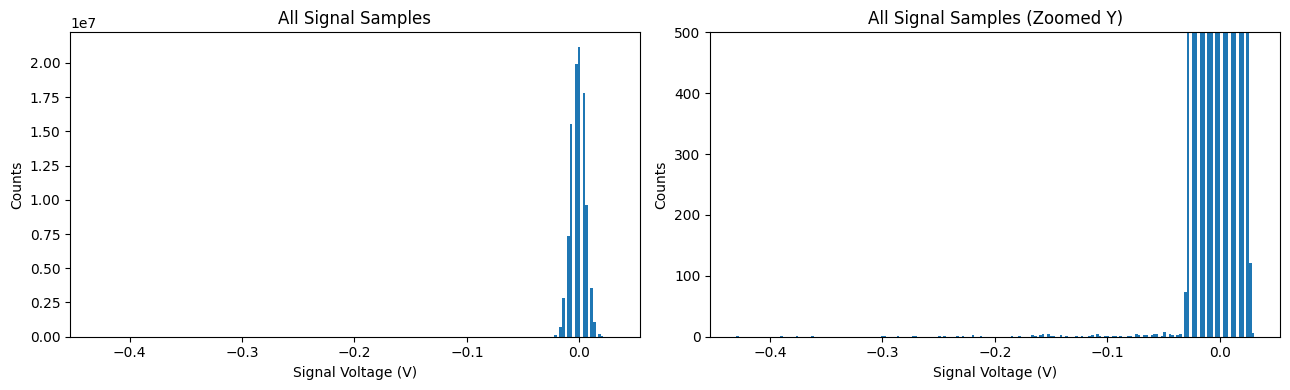

In [4]:
# Step 1: Load and summarize all signal samples.
# Each .npz file stores one waveform in the "signal" array. The notebook
# combines all waveform samples so the baseline/noise distribution can be
# inspected across the full acquisition set.
all_signal_chunks = []
total_signal_samples = 0

for file in npz_files:
    signal = load_signal(file)
    all_signal_chunks.append(signal)
    total_signal_samples += signal.size

all_signal = np.concatenate(all_signal_chunks)
signal_mean = float(np.mean(abs(all_signal)))
signal_std = float(np.std(all_signal))

print(f"Total number of files: {len(npz_files)}")
print(f"Total number of signal samples: {total_signal_samples}")
print(f"Signal mean: {signal_mean:.8g}")
print(f"Signal standard deviation: {signal_std:.8g}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

axes[0].hist(all_signal, bins=HIST_BINS)
axes[0].set_title("All Signal Samples")
axes[0].set_xlabel("Signal Voltage (V)")
axes[0].set_ylabel("Counts")

axes[1].hist(all_signal, bins=HIST_BINS)
axes[1].set_title("All Signal Samples (Zoomed Y)")
axes[1].set_xlabel("Signal Voltage (V)")
axes[1].set_ylabel("Counts")
axes[1].set_ylim(0, HIST_YMAX)

plt.tight_layout()
plt.show()


Total number of minima detected: 23211056


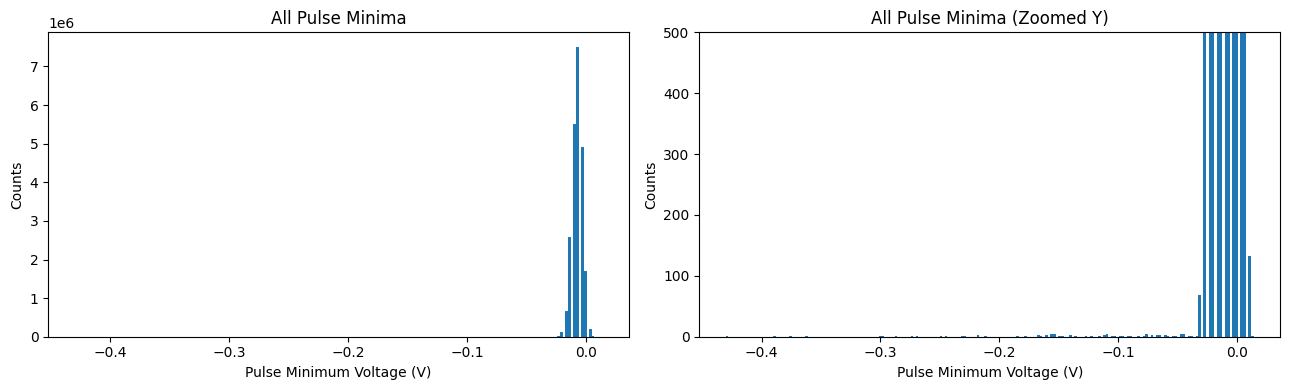

Noise reference from PMT=0 scope data:
Minimum observed noise voltage = -0.030717 V
Detected histogram local minima in the negative-voltage region, ranked by voltage:
Rank 1: Voltage = -0.005204825 V
Rank 2: Voltage = -0.011860175 V
Rank 3: Voltage = -0.018515525 V
Rank 4: Voltage = -0.025170875 V
Rank 5: Voltage = -0.029607775 V
Rank 6: Voltage = -0.036263125 V
Rank 7: Voltage = -0.042918475 V
Rank 8: Voltage = -0.049573825 V
Rank 9: Voltage = -0.056229175 V
Rank 10: Voltage = -0.062884525 V
Rank 11: Voltage = -0.069539875 V
Rank 12: Voltage = -0.073976775 V
Rank 13: Voltage = -0.080632125 V
Rank 14: Voltage = -0.087287475 V
Rank 15: Voltage = -0.093942825 V
Rank 16: Voltage = -0.10059818 V
Rank 17: Voltage = -0.10725353 V
Rank 18: Voltage = -0.11390887 V
Rank 19: Voltage = -0.12056422 V
Rank 20: Voltage = -0.12500112 V
Rank 21: Voltage = -0.13165647 V
Rank 22: Voltage = -0.13831182 V
Rank 23: Voltage = -0.14496718 V
Rank 24: Voltage = -0.15162253 V
Rank 25: Voltage = -0.15827788 V
Ra

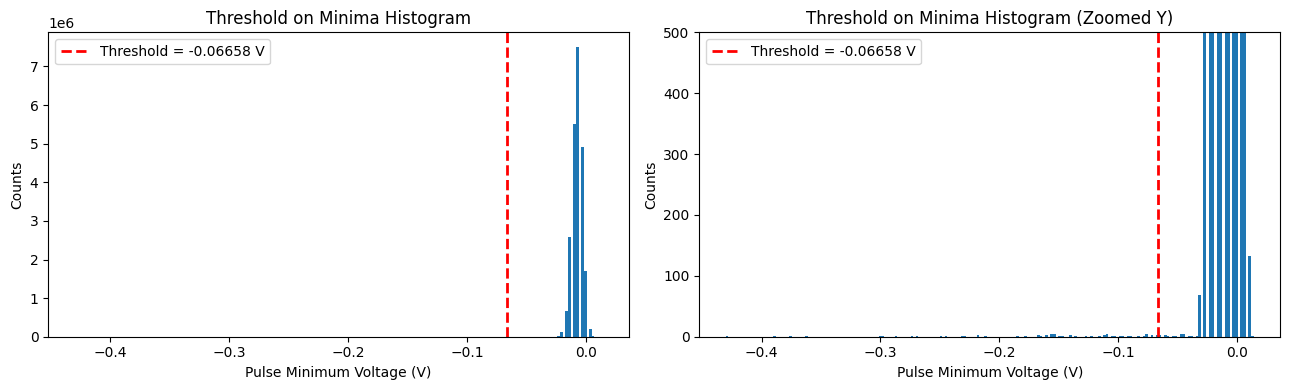

In [5]:
# Step 2: Find local minima and build the pulse-height histogram.
# The existing workflow is reused here: local minima are found by applying
# scipy.signal.find_peaks to -signal, then the corresponding signal voltages
# are collected across all files.
all_minima_chunks = []

for file in npz_files:
    signal = load_signal(file)

    peaks, properties = find_peaks(
        -signal,
        prominence=PROMINENCE,
        distance=MINIMA_DISTANCE,
    )
    all_minima_chunks.append(signal[peaks])

all_minima = np.concatenate(all_minima_chunks) if all_minima_chunks else np.array([])

print(f"Total number of minima detected: {len(all_minima)}")

minima_counts, minima_edges = np.histogram(all_minima, bins=HIST_BINS)
minima_centers = 0.5 * (minima_edges[:-1] + minima_edges[1:])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

axes[0].hist(all_minima, bins=minima_edges)
axes[0].set_title("All Pulse Minima")
axes[0].set_xlabel("Pulse Minimum Voltage (V)")
axes[0].set_ylabel("Counts")

axes[1].hist(all_minima, bins=minima_edges)
axes[1].set_title("All Pulse Minima (Zoomed Y)")
axes[1].set_xlabel("Pulse Minimum Voltage (V)")
axes[1].set_ylabel("Counts")
axes[1].set_ylim(0, HIST_YMAX)

plt.tight_layout()
plt.show()

# Step 3: Automatic threshold selection.
# Local minima in the negative-voltage side of the minima histogram mark valleys
# between pulse-height populations. A PMT=0 scope noise reference is used to reject
# candidate thresholds that are still inside the mean absolute noise level.
noise_data_dir = Path(NOISE_DATA_FOLDER)
noise_files = sorted(noise_data_dir.glob("*.npz"))

if not noise_files:
    raise FileNotFoundError(f"No .npz files found in noise reference folder: {noise_data_dir}")

noise_signal_chunks = []
for file in noise_files:
    noise_signal_chunks.append(load_signal(file))

all_noise_signal = np.concatenate(noise_signal_chunks)
noise_reference = np.min(all_noise_signal)

print("Noise reference from PMT=0 scope data:")
print(f"Minimum observed noise voltage = {noise_reference:.8g} V")

negative_mask = minima_centers < 0
negative_counts = minima_counts[negative_mask]
negative_centers = minima_centers[negative_mask]

hist_minima_indices, _ = find_peaks(-negative_counts, distance=1)
hist_minima_voltages = negative_centers[hist_minima_indices]
hist_minima_counts = negative_counts[hist_minima_indices]

candidates = sorted(
    zip(hist_minima_voltages, hist_minima_counts),
    key=lambda item: item[0],
    reverse=True,
)

print("Detected histogram local minima in the negative-voltage region, ranked by voltage:")
if candidates:
    for rank, (voltage, count) in enumerate(candidates, start=1):
        print(f"Rank {rank}: Voltage = {voltage:.8g} V")

    threshold = None
    print("Evaluating threshold candidates:")
    for voltage, count in candidates:
        if abs(voltage) > abs(noise_reference):
            threshold = float(voltage) - 5* signal_std # strict threshold
            #threshold = float(voltage) 
            print(f"{voltage:.8g} V -> accepted")
            break

        print(f"{voltage:.8g} V -> rejected (inside noise region)")

    if threshold is None:
        threshold = float(candidates[-1][0])
        print("Warning: no histogram minimum satisfies the noise threshold condition; falling back to the most negative detected histogram minimum.")
else:
    threshold = float(np.max(all_minima[all_minima < 0]))
    print("Warning: no histogram local minima detected below 0 V; using the negative minima value closest to 0 V.")

print(f"Final threshold = {threshold:.8g} V")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for ax, title in zip(axes, ["Threshold on Minima Histogram", "Threshold on Minima Histogram (Zoomed Y)"]):
    ax.hist(all_minima, bins=minima_edges)
    ax.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold = {threshold:.4g} V")
    ax.set_title(title)
    ax.set_xlabel("Pulse Minimum Voltage (V)")
    ax.set_ylabel("Counts")
    ax.legend()

axes[1].set_ylim(0, HIST_YMAX)

plt.tight_layout()
plt.show()


Mean photon count: 7.8
Photon count standard deviation: 5.3814496
Minimum photon count: 1
Maximum photon count: 19
Saved photon counts to: /Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/20260604_PMT_darkcount_control_voltage/PMT=0.65/data/photon_count_summary.csv


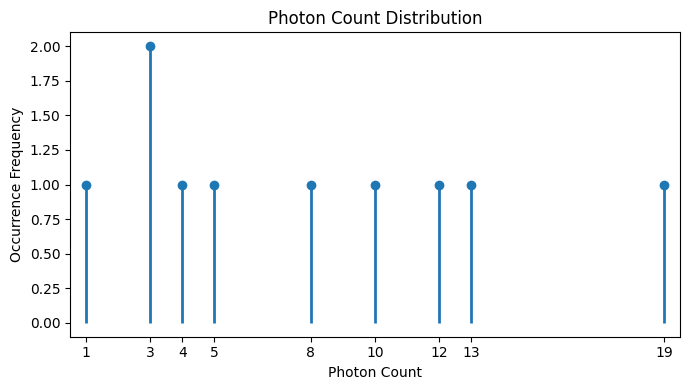

Saved final summary to: /Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/20260604_PMT_darkcount_control_voltage/PMT=0.65/data/final_summary.csv


| Metric | Value |
|---|---|
| Number of files | 10 |
| Total signal samples | 100000000 |
| Absolute signal mean | 0.00484803049195 |
| Signal std | 0.006062838262053506 |
| Number of minima | 23211056 |
| Threshold (V) | -0.06657731631026753 |
| Minimum photon count | 1 |
| Maximum photon count | 19 |
| Mean photon count | 7.8 |
| Std photon count | 5.381449618829484 |

In [6]:
# Step 4: Photon counting.
# Count photons directly from detected pulse minima.
# A photon event is defined as a local minimum whose voltage
# is below the selected threshold.

def count_photon_events(signal, threshold):
    peaks, _ = find_peaks(
        -signal,
        prominence=PROMINENCE,
        distance=MINIMA_DISTANCE,
    )

    valid_peaks = peaks[signal[peaks] < threshold]

    return int(len(valid_peaks))

photon_counts = []

for file in npz_files:
    signal = load_signal(file)

    photon_count = count_photon_events(
        signal,
        threshold,
    )

    photon_counts.append(
        {
            "filename": file.name,
            "photon_count": photon_count,
        }
    )

photon_count_values = np.array(
    [row["photon_count"] for row in photon_counts]
)

# Step 5: Photon count summary.
photon_summary_path = output_dir / "photon_count_summary.csv"

with photon_summary_path.open("w", newline="") as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=[
            "filename",
            "photon_count",
        ],
    )
    writer.writeheader()
    writer.writerows(photon_counts)

mean_photon_count = float(np.mean(photon_count_values))
std_photon_count = float(np.std(photon_count_values))
min_photon_count = int(np.min(photon_count_values))
max_photon_count = int(np.max(photon_count_values))

print(f"Mean photon count: {mean_photon_count:.8g}")
print(f"Photon count standard deviation: {std_photon_count:.8g}")
print(f"Minimum photon count: {min_photon_count}")
print(f"Maximum photon count: {max_photon_count}")
print(f"Saved photon counts to: {photon_summary_path.resolve()}")

from collections import Counter

counts = Counter(photon_count_values)

x = np.array(sorted(counts))
y = np.array([counts[k] for k in x])

plt.figure(figsize=(7, 4))
plt.vlines(x, 0, y, linewidth=2)
plt.plot(x, y, "o")
plt.xlabel("Photon Count")
plt.ylabel("Occurrence Frequency")
plt.title("Photon Count Distribution")
plt.xticks(x)
plt.xlim(x.min() - 0.5, x.max() + 0.5)
plt.tight_layout()
plt.show()

# Step 6: Final summary table.
summary_rows = [
    {"Metric": "Number of files", "Value": len(npz_files)},
    {"Metric": "Total signal samples", "Value": total_signal_samples},
    {"Metric": "Absolute signal mean", "Value": signal_mean},
    {"Metric": "Signal std", "Value": signal_std},
    {"Metric": "Number of minima", "Value": len(all_minima)},
    {"Metric": "Threshold (V)", "Value": threshold},
    {"Metric": "Minimum photon count", "Value": min_photon_count},
    {"Metric": "Maximum photon count", "Value": max_photon_count},
    {"Metric": "Mean photon count", "Value": mean_photon_count},
    {"Metric": "Std photon count", "Value": std_photon_count},
]

final_summary_path = output_dir / "final_summary.csv"

with final_summary_path.open("w", newline="") as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=["Metric", "Value"],
    )
    writer.writeheader()
    writer.writerows(summary_rows)

summary_table = "| Metric | Value |\n|---|---|\n" + "\n".join(
    f"| {row['Metric']} | {row['Value']} |"
    for row in summary_rows
)

print(f"Saved final summary to: {final_summary_path.resolve()}")
display(Markdown(summary_table))